We are building an image Classifier.

In [1]:
#Install and importing Libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
#Defining Transforms - normalize the images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

#Load CIFAR-10 dataset
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

#Create data loaders
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

#Class names in CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of testing samples: {len(test_dataset)}")

100%|██████████| 170M/170M [00:07<00:00, 23.9MB/s]


Number of training samples: 50000
Number of testing samples: 10000


In [4]:
from typing import Self
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()

    self.conv1 = nn. Conv2d(3,32,3, padding=1)
    self.conv2 = nn. Conv2d(32,64,3, padding=1)
    self.conv3 = nn. Conv2d(64,128,3, padding=1)

    self.pool = nn.MaxPool2d(2,2)

    self.fc1 = nn.Linear(128*4*4, 512)
    self.fc2 = nn.Linear(512, 10)

    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(0.5)

  def forward(self, x):
      x = self.pool(self.relu(self.conv1(x)))
      x = self.pool(self.relu(self.conv2(x)))
      x = self.pool(self.relu(self.conv3(x)))

      x = x.view(-1, 128*4*4)
      x = self.dropout(x)
      x = self.relu(self.fc1(x))
      x = self.dropout(x)
      x = self.fc2(x)

      return x

John_model = CNN().to(device)
print(John_model)


CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)


In [5]:
#Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(John_model.parameters(), lr=0.001)

#Training loop
def train(epochs):
  for epoch in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(trainloader):
      images, labels = images.to(device), labels.to(device)
      optimizer.zero_grad()
      outputs = John_model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()
      running_loss += loss.item()
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    print(f'Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(trainloader)}], Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%')

train(epochs=10)




Epoch [1/10], Step [1563/1563], Loss: 1.2311, Accuracy: 47.37%
Epoch [2/10], Step [1563/1563], Loss: 0.9703, Accuracy: 61.51%
Epoch [3/10], Step [1563/1563], Loss: 1.0250, Accuracy: 66.66%
Epoch [4/10], Step [1563/1563], Loss: 0.6968, Accuracy: 69.89%
Epoch [5/10], Step [1563/1563], Loss: 0.6956, Accuracy: 71.28%
Epoch [6/10], Step [1563/1563], Loss: 0.6031, Accuracy: 72.61%
Epoch [7/10], Step [1563/1563], Loss: 1.0811, Accuracy: 73.81%
Epoch [8/10], Step [1563/1563], Loss: 0.6845, Accuracy: 74.81%
Epoch [9/10], Step [1563/1563], Loss: 0.7210, Accuracy: 75.75%
Epoch [10/10], Step [1563/1563], Loss: 0.6358, Accuracy: 76.26%


In [6]:
def evaluate():
  John_model.eval()
  correct = 0
  total = 0

  with torch.no_grad():
    for images, labels in testloader:
      images, labels = images.to(device), labels.to(device)
      outputs = John_model(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

      accuracy = 100 * correct / total
    print(f'Accuracy on the test images: {accuracy:.2f}%')

evaluate()

Accuracy on the test images: 76.50%


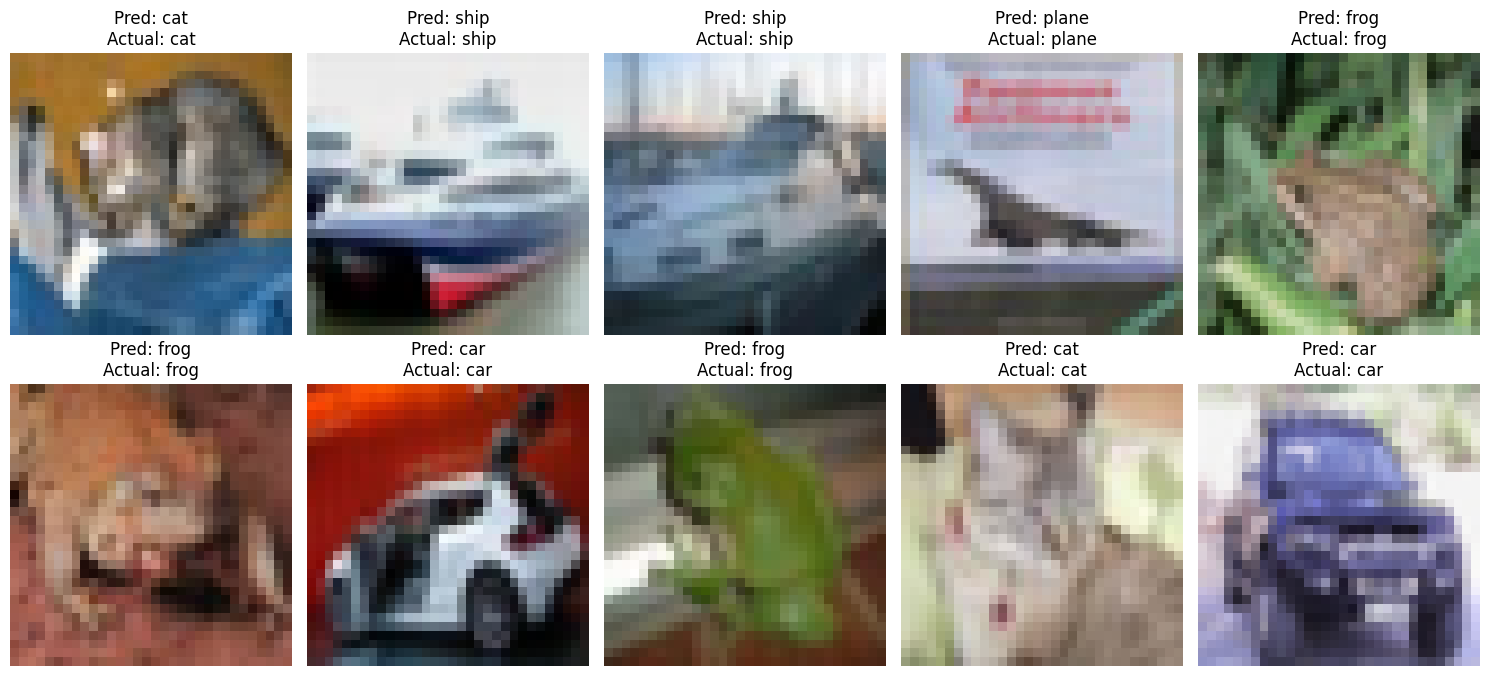

In [7]:
def visualize_predictions():
  John_model.eval()
  dataiter = iter(testloader)
  images, labels = next(dataiter)
  images, labels = images.to(device), labels.to(device)
  with torch.no_grad():
    outputs = John_model(images)
    _, predicted = torch.max(outputs, 1)

  fig, axes = plt.subplots(2,5, figsize =(15, 7))
  axes = axes.flatten()

  for i in range(10):
    img = images[i].cpu()/ 2 + 0.5
    axes[i].imshow(np.transpose(img.numpy(), (1,2,0)))
    axes[i].set_title(f"Pred: {classes[predicted[i]]}\nActual: {classes[labels[i]]}")
    axes[i].axis('off')

  plt.tight_layout()
  plt.show()

visualize_predictions()

In [8]:
def predict_and_show_image(image_path_or_url):
    # Ensure the model is in evaluation mode
    John_model.eval()

    # Preprocess the image
    input_tensor = preprocess_image(image_path_or_url)
    input_tensor = input_tensor.to(device)

    with torch.no_grad():
        outputs = John_model(input_tensor)
        _, predicted_idx = torch.max(outputs, 1)

    predicted_class = classes[predicted_idx.item()]

    # Display the image and prediction
    img = input_tensor.cpu().squeeze(0)
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()

    plt.figure(figsize=(6, 6))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')
    plt.show()

    return predicted_class

print("Defined predict_and_show_image function.")

Defined predict_and_show_image function.


In [9]:
torch.save(John_model.state_dict(), 'cifar10_cnn.pth')
print("Model saved successfully!")

Model saved successfully!


Defined preprocess_image function.
Please enter an image URL for prediction: https://th.bing.com/th/id/OIP.9AA9ELQUr6WsoCJ2WcVcEwHaEK?w=277&h=180&c=7&r=0&o=7&pid=1.7&rm=3
Predicting for: https://th.bing.com/th/id/OIP.9AA9ELQUr6WsoCJ2WcVcEwHaEK?w=277&h=180&c=7&r=0&o=7&pid=1.7&rm=3


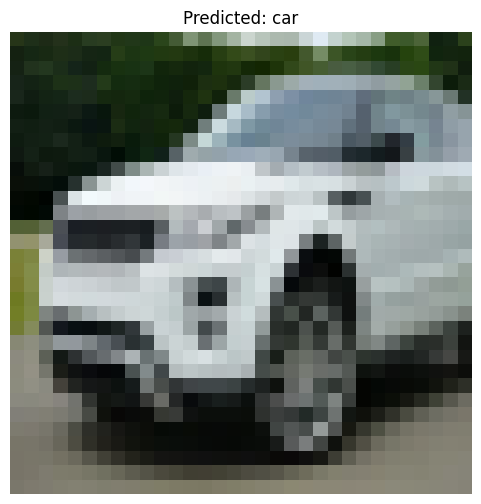

The model predicted: car


In [12]:
from PIL import Image
import requests
from io import BytesIO

def preprocess_image(image_path_or_url):
    if image_path_or_url.startswith('http'):
        response = requests.get(image_path_or_url)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        img = Image.open(BytesIO(response.content)).convert('RGB')
    else:
        img = Image.open(image_path_or_url).convert('RGB')

    # Resize the image to 32x32
    img = img.resize((32, 32))

    # Apply the same transform used for CIFAR-10
    # Note: 'transform' was defined earlier and includes ToTensor and Normalize
    img_tensor = transform(img)

    # Add a batch dimension
    return img_tensor.unsqueeze(0)

print("Defined preprocess_image function.")


# Ask user for an image link
user_image_url = input("Please enter an image URL for prediction: ")

# Predict and show the image
print(f"Predicting for: {user_image_url}")
predicted_class = predict_and_show_image(user_image_url)
print(f"The model predicted: {predicted_class}")